#### **Decision Tree-Based Stroke Prediction Analysis**
- This analysis provides an overview of using machine learning to predict stroke
- It addresses the challenge of data imbalance by employing strategic techniques

In [7]:
# import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shap
import lightgbm as lgb
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from scipy.stats import randint, uniform

import warnings
warnings.filterwarnings('ignore')

#### **Load data and preprocess**
- This is the stroke dataset which contains 5110 observations with 12 attributes.
- Kaggle link: [Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset)

In [8]:
# data loading
stroke_df = pd.read_csv('healthcare-dataset-stroke-data.csv')
stroke_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
# remove 'id' column as it is not a feature
stroke_df = stroke_df.drop(columns=['id'])

In [10]:
print("Shape of the dataset:", stroke_df.shape)

Shape of the dataset: (5110, 11)


In [ ]:
# get info about the dataset
stroke_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [12]:
# drop rows with missing values
stroke_df = stroke_df.dropna()
print("Shape of the dataset after dropping missing values:", stroke_df.shape)
stroke_df.head()

Shape of the dataset after dropping missing values: (4909, 11)


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


In [ ]:
# encode categorical variables into numerical format
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
le = LabelEncoder()
for col in categorical_cols:
    stroke_df[col] = le.fit_transform(stroke_df[col])

In [14]:
# define features X and target y 
X = stroke_df.drop(columns=['stroke'])
y = stroke_df['stroke']
feature_names = X.columns.tolist()
class_names = ['no_stroke', 'stroke']

In [15]:
# split the data into training and testing sets, ensuring stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [16]:
# step 2: baseline decision tree
# train a baseline decision tree classifier

dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)

# predict on the test set
y_pred_base = dt_baseline.predict(X_test)

In [17]:
# print baseline accuracy and classification report
print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred_base):.2f}")
print("\nBaseline Classification Report:")
print(classification_report(y_test, y_pred_base, target_names=class_names))

Baseline Accuracy: 0.92

Baseline Classification Report:
              precision    recall  f1-score   support

   no_stroke       0.96      0.96      0.96      1410
      stroke       0.08      0.08      0.08        63

    accuracy                           0.92      1473
   macro avg       0.52      0.52      0.52      1473
weighted avg       0.92      0.92      0.92      1473



Baseline descision tree model:
- The initial decision tree model had a high overall accuracy of 92%, but it performed poorly on the "stroke" class, with an f1-score of 0.08. This indicates that the model was likely predicting the majority class ("no_stroke") most of the time due to the data's imbalance.

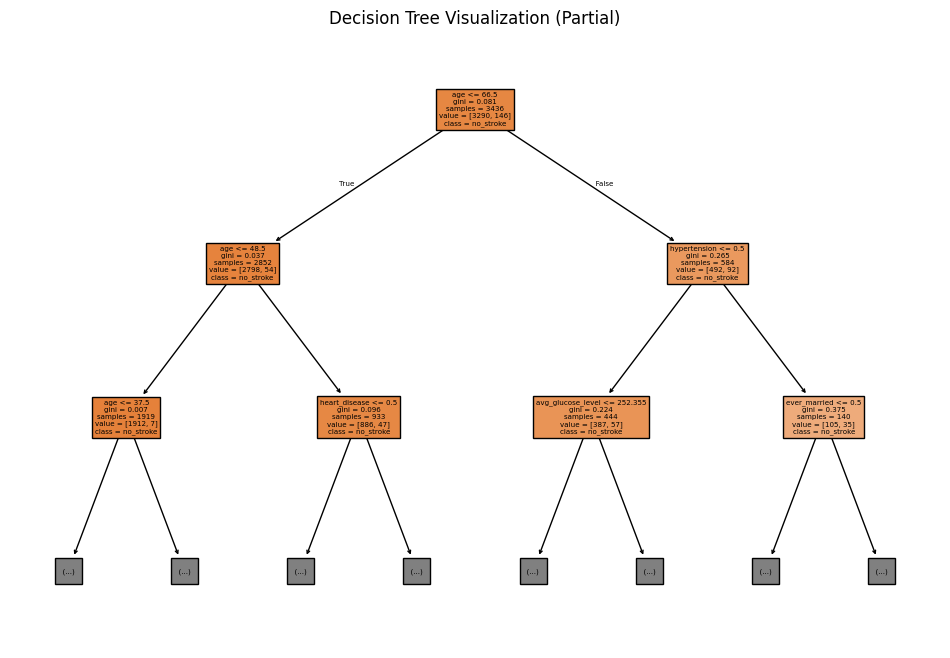

In [18]:
# visualize the baseline tree
plt.figure(figsize=(12, 8))
plot_tree(dt_baseline, max_depth=2, feature_names=feature_names, class_names=class_names, filled=True)
plt.title("Decision Tree Visualization (Partial)")
plt.show()

In [19]:
# step 3: Hyperparameter Tuning 
# Grid Search
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print(f"\nGrid Search Best Params: {grid_search.best_params_}")
print(f"Grid Search Best CV Score: {grid_search.best_score_:.2f}")


Grid Search Best Params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Grid Search Best CV Score: 0.96


Hyperparameter tuning:
- Grid Search on the baseline model resulted in an improved cross-validation score of 0.96.

In [20]:
# step 4: Hyperparameter Tuning - Random Search & SHAP Plotting
# calculate class weights to handle the severe class imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

print(f"\nCalculated class weights: {class_weight_dict}")


Calculated class weights: {np.int64(0): np.float64(0.5221884498480243), np.int64(1): np.float64(11.767123287671232)}


Dealing with class imbalance:
- The data is highly imblanced with "stroke" class having low frequency.
- Class weights are included by assigning weight of 0.52 to "no_stroke" class and a much higher weight of 11.77 to "stroke" class

In [21]:
# define the parameter distribution for Random Search
param_dist = {
    'n_estimators': randint(50, 200),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10)
}

# use RandomizedSearchCV with the calculated class weights
random_search = RandomizedSearchCV(
    estimator=lgb.LGBMClassifier(random_state=42, verbose=-1, class_weight=class_weight_dict),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

In [22]:
# fit the random search model
random_search.fit(X_train, y_train)

# get the best model from the search
best_lgbm = random_search.best_estimator_
y_pred_tuned = best_lgbm.predict(X_test)

# print the classification report to show performance
print("\nTuned Classification Report with Class Weights:")
print(classification_report(y_test, y_pred_tuned, target_names=class_names))


Tuned Classification Report with Class Weights:
              precision    recall  f1-score   support

   no_stroke       0.97      0.88      0.92      1410
      stroke       0.11      0.33      0.17        63

    accuracy                           0.86      1473
   macro avg       0.54      0.61      0.54      1473
weighted avg       0.93      0.86      0.89      1473



Tuned model:
- After triaining the model with class weights, the overall accuracy decreased to 86%. But the recall for "stroke" class improved to 0.33 which shows the model is now better at identifying positive cases
- The precision for the "stroke" class is 0.11, indicating that the model still struggles with false positives.

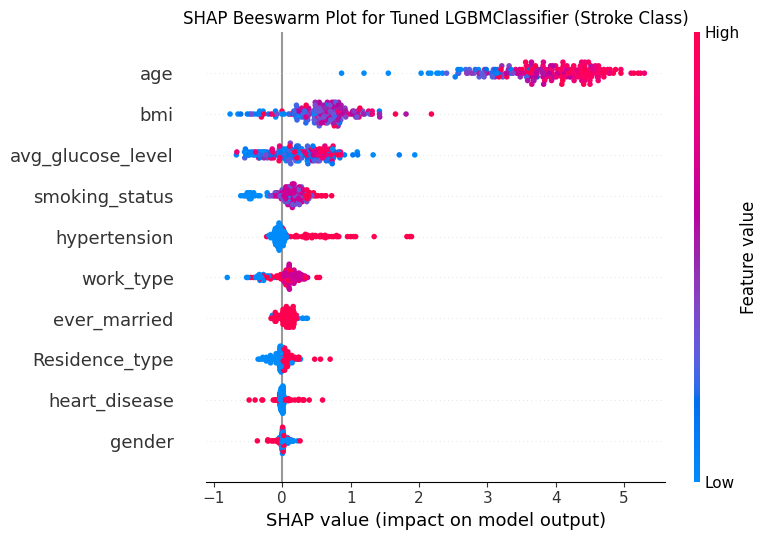


Successfully generated SHAP plot as 'shap_beeswarm_plot.png'.


In [23]:
# generate and Plot SHAP Values

# get the tuned model's predictions on the test set
y_pred_tuned = best_lgbm.predict(X_test)

# identify the indices of samples where a stroke was predicted
stroke_indices = np.where(y_pred_tuned == 1)[0]

# filter the test data to only include the samples predicted as 'stroke'
if len(stroke_indices) > 0:
    X_test_stroke = X_test.iloc[stroke_indices]

    # calculate SHAP values specifically for the filtered 'stroke' predictions
    explainer = shap.TreeExplainer(best_lgbm)
    shap_values_stroke = explainer.shap_values(X_test_stroke)

    # convert the SHAP values for the 'stroke' class into a 2D matrix
    if isinstance(shap_values_stroke, list):
        shap_values_stroke = shap_values_stroke[1]
    
    # reshape the 1D array into a 2D matrix to meet the plotting requirement
    shap_values_stroke = np.reshape(shap_values_stroke, (-1, X_test_stroke.shape[1]))

    # plot the SHAP values
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_stroke, X_test_stroke, feature_names=X.columns.tolist(), show=False)
    plt.title("SHAP Beeswarm Plot for Tuned LGBMClassifier (Stroke Class)")
    plt.tight_layout()
    plt.savefig('shap_beeswarm_plot.png')
    plt.show()

    print("\nSuccessfully generated SHAP plot as 'shap_beeswarm_plot.png'.")
else:
    print("\nCould not generate SHAP plot. The model did not predict any 'stroke' cases.")




SHAP plot:
- X-axis represents the impact of each feature on model's output with positive SHAP values push the model's prediction higher, increasing the likelihood of the stroke.
- On y-axis, the features are sorted by their overall importance - features at the top have the largest impact on model's prediction. age, avg_glucose_level and bmi are the most influential features.